In [1]:
from nested_pandas import read_parquet
import matplotlib.pyplot as plt
import numpy as np
import sncosmo
import pandas as pd

from pathlib import Path
outdir = Path('outputs/')

In [2]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None,set_ylim=True):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.5*maxflux, maxflux*1.5)
    else:
        ylim = (-0.5*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    if set_ylim:
        plt.ylim(ylim)

In [3]:
ddf = read_parquet(outdir / "final_sample_ddf.parquet")
full = read_parquet(outdir / "final_sample.parquet")
fastdb = read_parquet("../../rubin_alerts/output/fastdb_filtered_objects_071726.parquet")

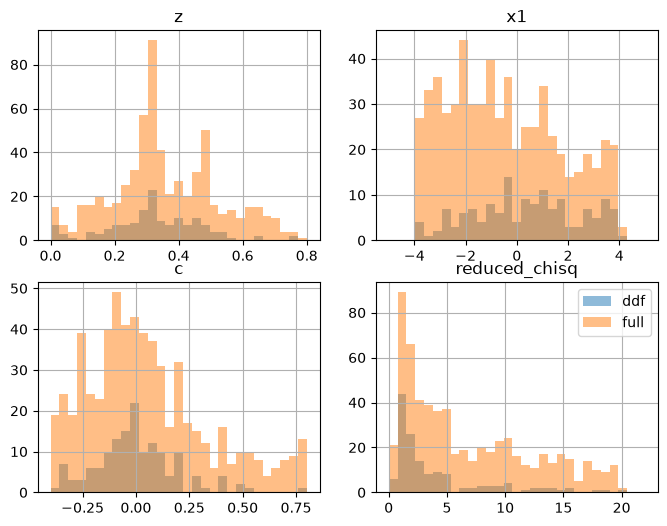

In [4]:
fig = plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
bins = np.linspace(0,0.8,30)
ddf.z.hist(bins=bins, label="ddf",alpha=0.5)
full.z.hist(bins=bins, label="full",alpha=0.5)
plt.title("z")
plt.subplot(2,2,2)
bins = np.linspace(-5,5,30)
ddf.x1.hist(bins=bins, label="ddf",alpha=0.5)
full.x1.hist(bins=bins, label="full",alpha=0.5)
plt.title("x1")
plt.subplot(2,2,3)
bins = np.linspace(-0.4,0.8,30)
ddf.c.hist(bins=bins, label="ddf",alpha=0.5)
full.c.hist(bins=bins, label="full",alpha=0.5)
plt.title("c")
plt.subplot(2,2,4)
bins = np.linspace(0,22,30)
ddf.reduced_chisq.hist(bins=bins, label="ddf",alpha=0.5)
full.reduced_chisq.hist(bins=bins, label="full",alpha=0.5)
plt.title("reduced_chisq")
plt.legend()
plt.show()

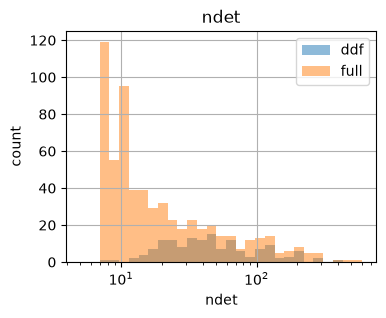

In [5]:
fig = plt.figure(figsize=(4,3))
bins = np.logspace(np.log10(5), np.log10(600), 30)  # avoid 0 for log bins
ddf["ndet"].hist(bins=bins, label="ddf", alpha=0.5)
full["ndet"].hist(bins=bins, label="full", alpha=0.5)
plt.xscale('log')
plt.xlabel("ndet")
plt.ylabel("count")
plt.legend()
plt.title("ndet")
plt.show()

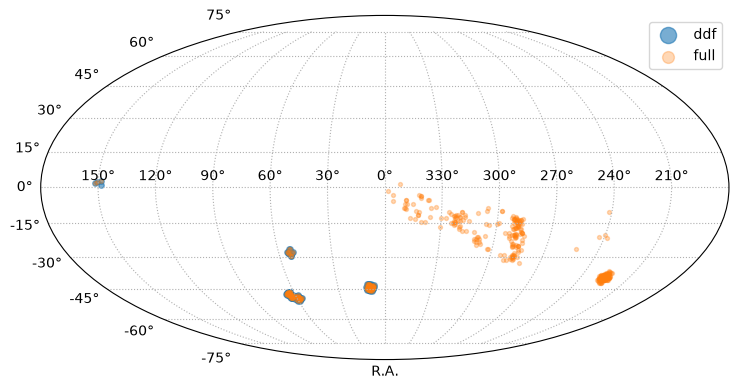

In [6]:
CENTER = 0

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111, projection='mollweide')

def plot_radec(ra, dec, center=CENTER, flip=True, **kwargs):
    ra = np.asarray(ra, dtype=float)
    dec = np.asarray(dec, dtype=float)
    ra_shifted = np.remainder(ra - center + 180, 360) - 180
    x = -ra_shifted if flip else ra_shifted
    ax.scatter(np.radians(x), np.radians(dec), **kwargs)

plot_radec(ddf["ra_dia_object_lc"].to_numpy(dtype=float), ddf["dec_dia_object_lc"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="ddf")
plot_radec(full["ra_dia_object_lc"].to_numpy(dtype=float), full["dec_dia_object_lc"].to_numpy(dtype=float),
           s=8, alpha=0.3, label="full")

tick_vals = np.array([-150,-120,-90,-60,-30,0,30,60,90,120,150])
tick_labels = [f"{int(np.remainder(CENTER - t, 360))}°" for t in tick_vals]
ax.set_xticks(np.radians(tick_vals))
ax.set_xticklabels(tick_labels)

ax.grid(True, linestyle=':')
ax.legend(markerscale=3, loc='upper right')
ax.set_xlabel("R.A.")
plt.tight_layout()
plt.show()

In [7]:
col = "diaObjectId_dia_object_lc"  # change to whatever column

set_ddf = set(ddf[col].dropna())
set_full = set(full[col].dropna())

overlap = set_ddf & set_full

print(f"ddf: {len(set_ddf)} unique values")
print(f"full: {len(set_full)} unique values")
print(f"overlap: {len(overlap)} values")
print(f"overlap fraction of ddf: {len(overlap)/len(set_ddf):.2%}")
print(f"overlap fraction of full: {len(overlap)/len(set_full):.2%}")

ddf: 145 unique values
full: 617 unique values
overlap: 141 values
overlap fraction of ddf: 97.24%
overlap fraction of full: 22.85%


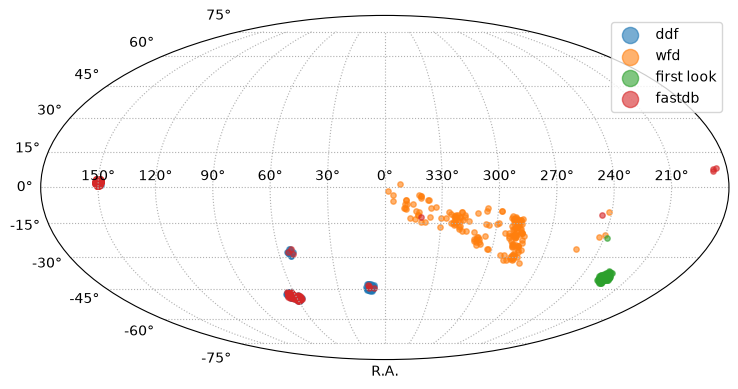

476


In [8]:
not_in_ddf = full[~full[col].isin(ddf[col])]
wfd = not_in_ddf[not_in_ddf["ra_dia_object_lc"] > 240]
first_look = not_in_ddf[not_in_ddf["ra_dia_object_lc"] < 240]

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111, projection='mollweide')
plot_radec(ddf["ra_dia_object_lc"].to_numpy(dtype=float), ddf["dec_dia_object_lc"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="ddf")
plot_radec(wfd["ra_dia_object_lc"].to_numpy(dtype=float), wfd["dec_dia_object_lc"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="wfd")
plot_radec(first_look["ra_dia_object_lc"].to_numpy(dtype=float), first_look["dec_dia_object_lc"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="first look")
plot_radec(fastdb["ra"].to_numpy(dtype=float), fastdb["dec"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="fastdb")
tick_vals = np.array([-150,-120,-90,-60,-30,0,30,60,90,120,150])
tick_labels = [f"{int(np.remainder(CENTER - t, 360))}°" for t in tick_vals]
ax.set_xticks(np.radians(tick_vals))
ax.set_xticklabels(tick_labels)

ax.grid(True, linestyle=':')
ax.legend(markerscale=3, loc='upper right')
ax.set_xlabel("R.A.")
plt.tight_layout()
plt.show()
print(len(not_in_ddf))

{'x0': 4.281546073711045e-05, 'x1': -3.3659914383231, 'c': -0.001993160560509767, 'z': 0.7089052016326696, 'mwebv': 0.06068757203370719, 't0': 60841.974514815396}
dist,reduced_chi2= 3.662328213159211 3.464311141523854


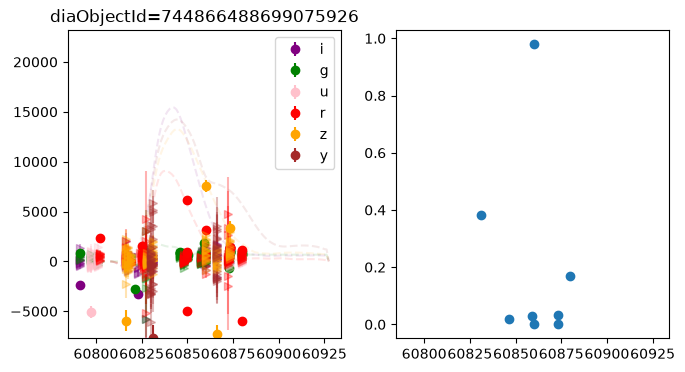

{'x0': 3.84206827831624e-05, 'x1': -2.1848369607795295, 'c': 0.652020659284643, 'z': 0.1210896387639083, 'mwebv': 0.07512820936749903, 't0': 60839.25013635307}
dist,reduced_chi2= 4.818497326006765 1.8909203433395494


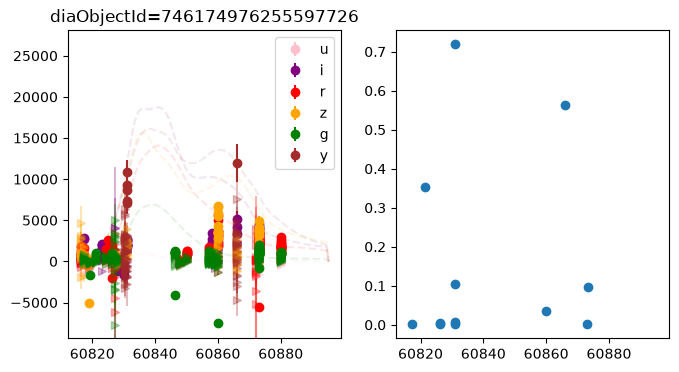

{'x0': 2.3224585189245372e-05, 'x1': -2.1762390871460546, 'c': 0.344751067223395, 'z': 0.28538029674211524, 'mwebv': 0.08228507048559987, 't0': 60850.7665461198}
dist,reduced_chi2= 1.1668294434548436 10.533397583766023


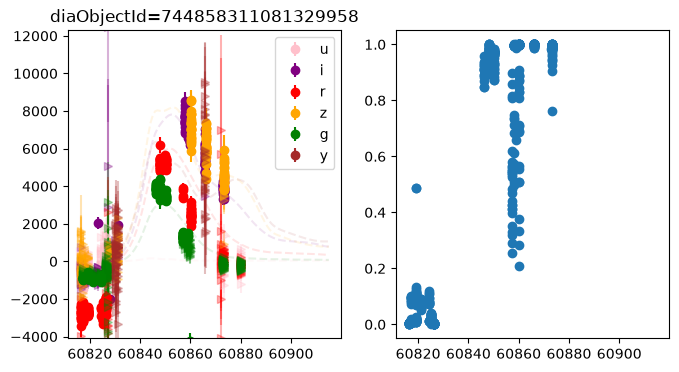

{'x0': 3.4422487699606126e-05, 'x1': -0.7466068063365369, 'c': -0.10647670016002914, 'z': 0.3958433984039093, 'mwebv': 0.09079574848964149, 't0': 60835.85160178931}
dist,reduced_chi2= 3.5893981730818285 6.541632000099063


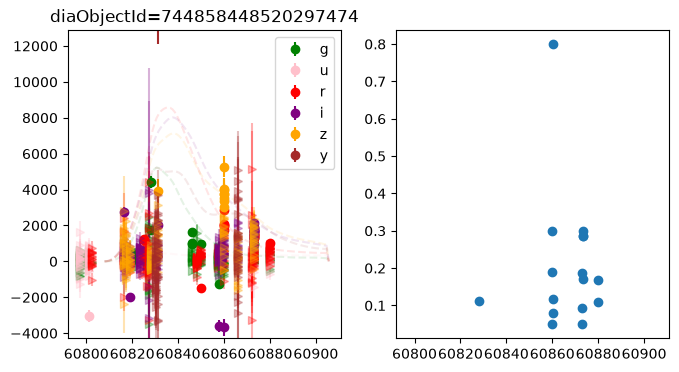

{'x0': 3.269317105716226e-05, 'x1': -2.23318193681714, 'c': -0.14945297595771234, 'z': 0.4053991734945896, 'mwebv': 0.07085187158963281, 't0': 60842.41108670358}
dist,reduced_chi2= 4.0778266729488415 17.769701582038717


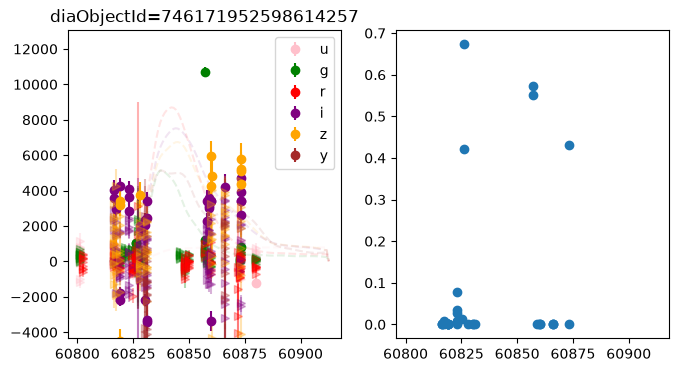

{'x0': 9.432893509217509e-06, 'x1': 0.579460108396364, 'c': 0.10995585202887109, 'z': 0.30501273693700426, 'mwebv': 0.08168786284507462, 't0': 60862.782966645915}
dist,reduced_chi2= 4.8740120162955956 18.364981703354406


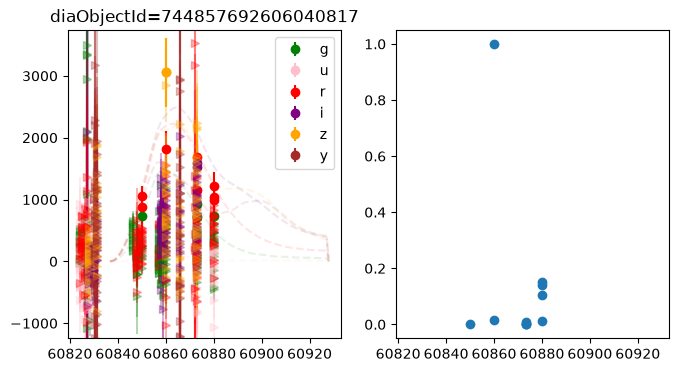

{'x0': 4.086995890967357e-05, 'x1': -1.7571900828111267, 'c': -0.15326283564771156, 'z': 0.6748144556338179, 'mwebv': 0.08203835803812723, 't0': 60837.91471629948}
dist,reduced_chi2= 4.487721065227732 8.993365873699114


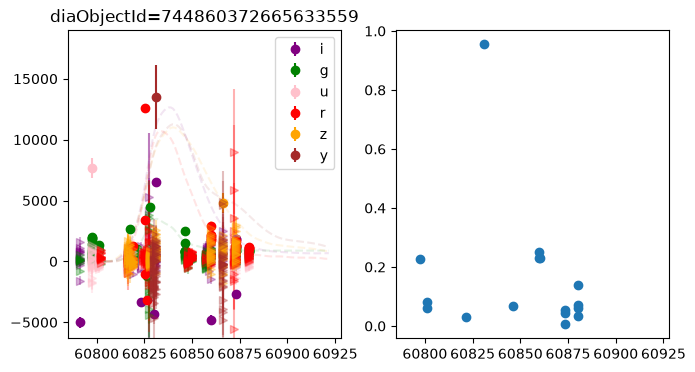

{'x0': 1.4045696580958901e-05, 'x1': 1.5152532230937619, 'c': -0.1331543578166341, 'z': 0.27983483640757323, 'mwebv': 0.09486146130334384, 't0': 60865.82287746327}
dist,reduced_chi2= 3.94741377727843 13.139822679791472


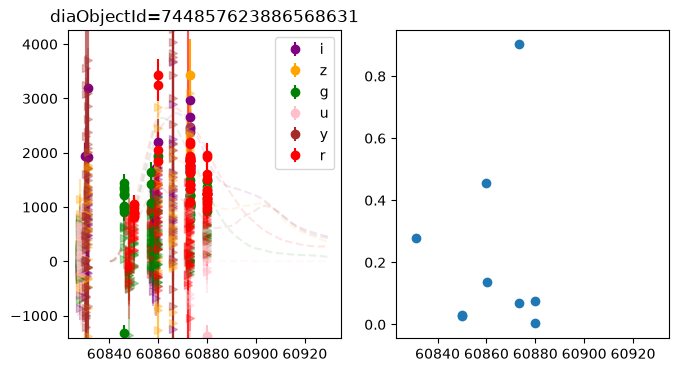

{'x0': 2.031855079866228e-05, 'x1': -3.336392644455722, 'c': 0.04364840011613801, 'z': 0.29502523388455215, 'mwebv': 0.08705670039494529, 't0': 60857.50400456288}
dist,reduced_chi2= 3.9990961663785733 6.2059164456473095


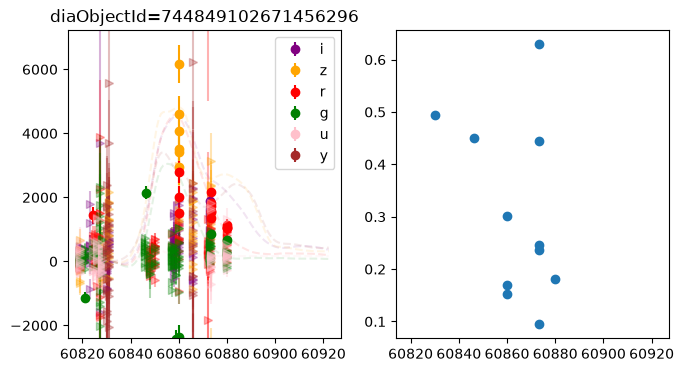

{'x0': 2.549966040164711e-05, 'x1': -0.5820190236964774, 'c': 0.3169643138520644, 'z': 0.16411569150683777, 'mwebv': 0.09586657567022873, 't0': 60840.918770206954}
dist,reduced_chi2= 3.5022804791528332 14.292968394694636


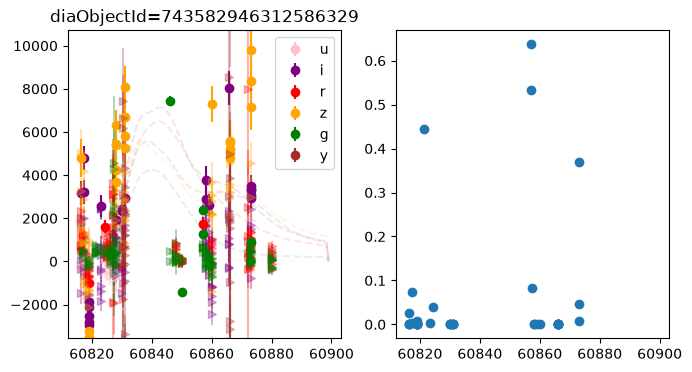

{'x0': 3.0803336682209154e-05, 'x1': -3.777986086261798, 'c': -0.03460117597808321, 'z': 0.34711833473880854, 'mwebv': 0.07233621044014532, 't0': 60864.5399576347}
dist,reduced_chi2= 0.893109135684159 3.161968304862695


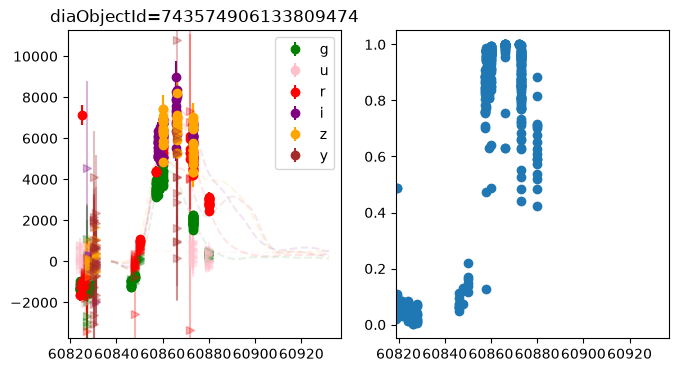

{'x0': 3.751670484567791e-05, 'x1': 1.2571530667127813, 'c': -0.2286714725364704, 'z': 0.17193327735282443, 'mwebv': 0.07178712269379357, 't0': 60835.60405487806}
dist,reduced_chi2= 4.159873475509485 15.438895412188472


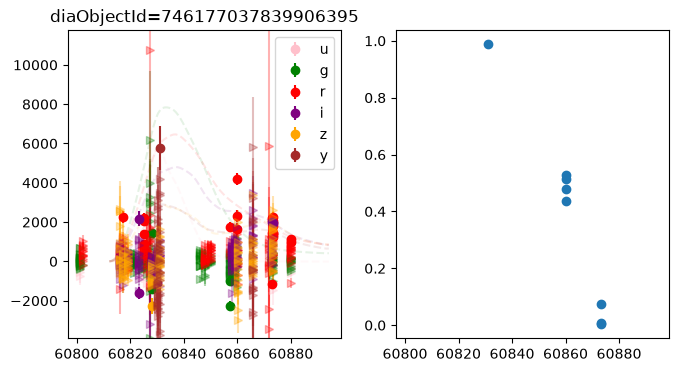

{'x0': 7.192166833202036e-05, 'x1': -2.147317687599611, 'c': -0.057365730834662884, 'z': 0.5545516752653915, 'mwebv': 0.06369066084181932, 't0': 60810.48562075475}
dist,reduced_chi2= 1.460425169908089 2.1893601354911616


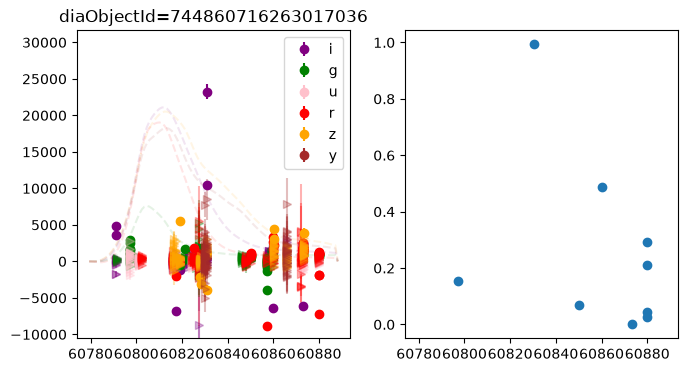

{'x0': 2.9420830335199584e-05, 'x1': -3.273176241914346, 'c': 0.19992938509242297, 'z': 0.28131894018927095, 'mwebv': 0.07950629509719775, 't0': 60837.63016696767}
dist,reduced_chi2= 4.1256231848835165 6.048519008885141


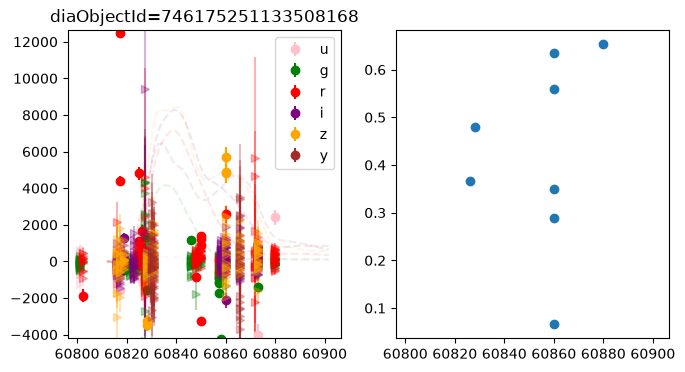

{'x0': 8.245672663764252e-06, 'x1': -3.21263548889324, 'c': 0.6607716389654334, 'z': 0.16468308958566366, 'mwebv': 0.07150329710998125, 't0': 60853.415687221954}
dist,reduced_chi2= 4.070207143545928 3.2502233221116827


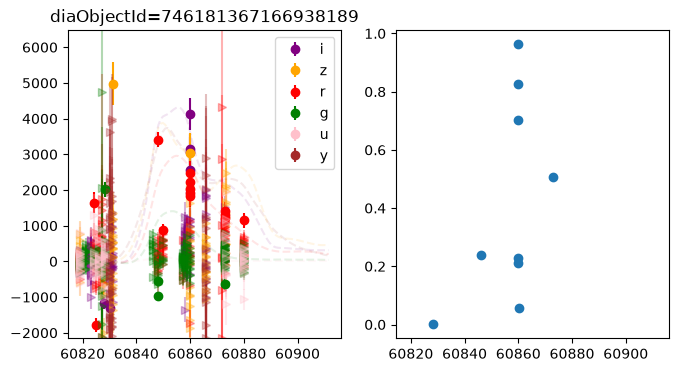

{'x0': 3.6453642884079425e-05, 'x1': 0.932477187916509, 'c': -0.003288441228544066, 'z': 0.5894310870451341, 'mwebv': 0.07572484924828585, 't0': 60835.64136396811}
dist,reduced_chi2= 3.8716048777841654 18.145314069771217


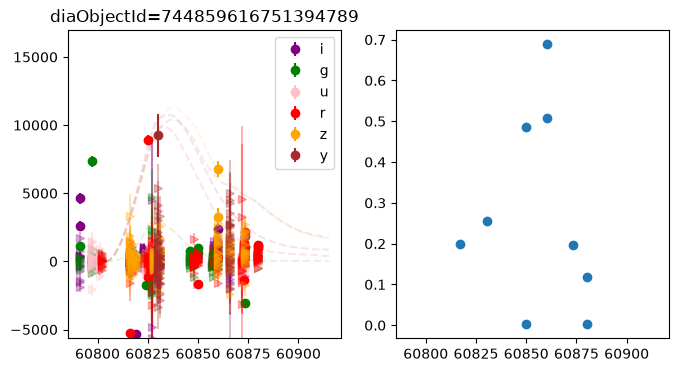

{'x0': 3.7636575365106806e-05, 'x1': -0.4367723474853374, 'c': 0.2335713838866586, 'z': 0.23337364104119807, 'mwebv': 0.07489458115013632, 't0': 60833.61971008528}
dist,reduced_chi2= 4.475342831269112 9.4083583208977


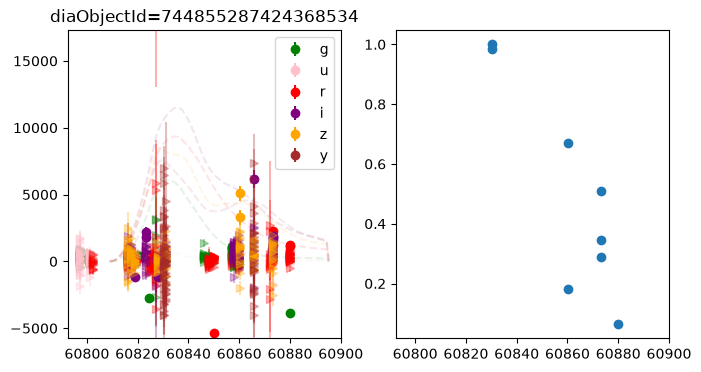

{'x0': 8.858982568911561e-06, 'x1': -0.670199333803324, 'c': 0.7976937060410295, 'z': 0.27535072575386077, 'mwebv': 0.07258535731719455, 't0': 60854.48577672904}
dist,reduced_chi2= 3.614318871431392 3.0990152773230033


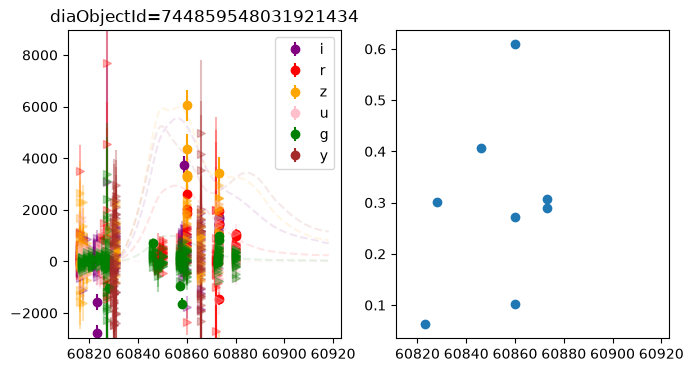

{'x0': 0.00013290116652602192, 'x1': -2.2104237806235045, 'c': -0.27792251921688693, 'z': 0.21449838820566083, 'mwebv': 0.09297390681387926, 't0': 60842.30338492209}
dist,reduced_chi2= 4.816161239286718 9.530890433909239


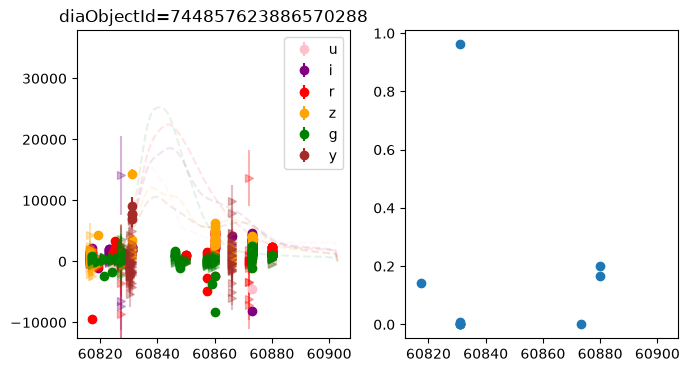

{'x0': 0.0001854586539056382, 'x1': -2.9305162169469505, 'c': -0.3047732947760358, 'z': 0.15068067733380225, 'mwebv': 0.08142190931971094, 't0': 60822.22779193686}
dist,reduced_chi2= 4.42604769529857 2.397972358053444


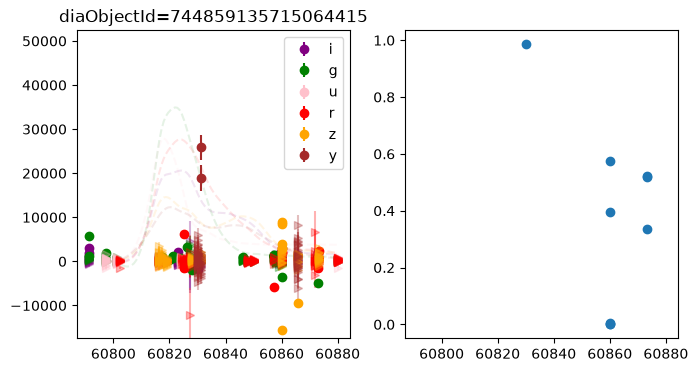

In [9]:
sn = first_look
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    saltpars_df = sn.iloc[i]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col]
    print(saltpars)
    print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(sn.iloc[i]["reduced_chisq"]))
    plt.figure(figsize=(12,4))
    ax = plt.subplot(1,3,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -30) & (phase < 100)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    # lc_coadd = nightly_coadd(lc["mjd"],lc["band"],lc["flux"],lc["fluxerr"])
    # lc_coadd["snr"] = lc_coadd["flux"]/lc_coadd["fluxerr"]
    # plot_lc(lc_coadd,saltpars=saltpars)
    plot_lc(lc,saltpars=saltpars)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(1,3,1)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax2 = plt.subplot(1,3,2)
    plt.plot(sn.iloc[i]["diaSource_dia_object_lc"]["midpointMjdTai"],sn.iloc[i]["diaSource_dia_object_lc"]["reliability"],'o')
    plt.xlim(ax.get_xlim())
    # ax = plt.subplot(1,3,3)
    # ra = sn.iloc[i]["ra_dia_object_lc"]
    # dec = sn.iloc[i]["dec_dia_object_lc"]
    # img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [10]:
tns = pd.read_csv("data/tns_search.csv")

In [11]:
from astropy.coordinates import SkyCoord
import astropy.units as u

ra_col, dec_col = "ra_dia_object_lc", "dec_dia_object_lc"     # full's columns

coords = SkyCoord(ra=tns["RA"], dec=tns["DEC"], unit=(u.hourangle, u.deg))

tns["ra_deg"] = coords.ra.degree
tns["dec_deg"] = coords.dec.degree

tns_ra_col, tns_dec_col = "ra_deg", "dec_deg"                  # tns's columns — check actual names

coords_full = SkyCoord(ra=full[ra_col].to_numpy(dtype=float)*u.deg,
                       dec=full[dec_col].to_numpy(dtype=float)*u.deg)
coords_tns = SkyCoord(ra=tns[tns_ra_col].to_numpy(dtype=float)*u.deg,
                      dec=tns[tns_dec_col].to_numpy(dtype=float)*u.deg)

idx, sep2d, _ = coords_full.match_to_catalog_sky(coords_tns)

tol = 5.0 * u.arcsec  # adjust match radius — TNS positions often coarser, consider 2-5 arcsec
is_match = sep2d < tol

matched_full = full[is_match].copy()
matched_full["tns_sep_arcsec"] = sep2d[is_match].arcsec
matched_full["tns_idx"] = idx[is_match]  # row index into tns

# pull matched TNS info alongside
matched_tns = tns.iloc[idx[is_match]].reset_index(drop=True)
matched_full = matched_full.reset_index(drop=True)
result = pd.concat([matched_full, matched_tns.add_prefix("tns_")], axis=1)

print(f"{is_match.sum()} / {len(full)} rows in full matched to a TNS source within {tol}")
result.head()

0 / 617 rows in full matched to a TNS source within 5.0 arcsec


,diaObjectId_dia_object_lc,ra_dia_object_lc,dec_dia_object_lc,refExtendedness_object_lc,refSizeExtendedness_object_lc,objectId_object_lc,coord_ra_object_lc,coord_dec_object_lc,_dist_arcsec,ndet,max_reliability,max_snr,median_flux_diff_ratio,median_flux_diff_ratio_abs,nbands,n_g,n_r,n_i,n_z,dt,bazin_fit_amplitude_g,bazin_fit_baseline_g,bazin_fit_reference_time_g,bazin_fit_rise_time_g,bazin_fit_fall_time_g,bazin_fit_reduced_chi2_g,bazin_fit_amplitude_r,bazin_fit_baseline_r,bazin_fit_reference_time_r,bazin_fit_rise_time_r,bazin_fit_fall_time_r,bazin_fit_reduced_chi2_r,bazin_fit_amplitude_i,bazin_fit_baseline_i,bazin_fit_reference_time_i,bazin_fit_rise_time_i,bazin_fit_fall_time_i,bazin_fit_reduced_chi2_i,bazin_fit_amplitude_z,bazin_fit_baseline_z,bazin_fit_reference_time_z,bazin_fit_rise_time_z,bazin_fit_fall_time_z,bazin_fit_reduced_chi2_z,chi2_g,chi2_r,chi2_i,chi2_z,diaObjectForcedSource_dia_object_lc,diaSource_dia_object_lc,pass_quality_cut,z_est,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,x1,x1_err,c,c_err,mwebv,mwebv_err,z_z_cov,z_t0_cov,z_x0_cov,z_x1_cov,z_c_cov,z_mwebv_cov,t0_z_cov,t0_t0_cov,t0_x0_cov,t0_x1_cov,t0_c_cov,t0_mwebv_cov,x0_z_cov,x0_t0_cov,x0_x0_cov,x0_x1_cov,x0_c_cov,x0_mwebv_cov,x1_z_cov,x1_t0_cov,x1_x0_cov,x1_x1_cov,x1_c_cov,x1_mwebv_cov,c_z_cov,c_t0_cov,c_x0_cov,c_x1_cov,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error,_healpix_29,reduced_chisq,pass_quality_cuts,__index_level_0__,tns_sep_arcsec,tns_idx,tns_ID,tns_Name,tns_RA,tns_DEC,tns_Obj. Type,tns_Redshift,tns_Host Name,tns_Host Redshift,tns_Reporting Group/s,tns_Discovery Data Source/s,tns_Classifying Group/s,tns_Associated Group/s,tns_Disc. Internal Name,tns_Disc. Instrument/s,tns_Class. Instrument/s,tns_TNS AT,tns_Public,tns_End Prop. Period,tns_Discovery Mag/Flux,tns_Discovery Filter,tns_Discovery Date (UT),tns_Sender,tns_Remarks,tns_Unreal,tns_Discovery Bibcode,tns_Classification Bibcodes,tns_Ext. catalog/s,tns_Auto classification,tns_ra_deg,tns_dec_deg


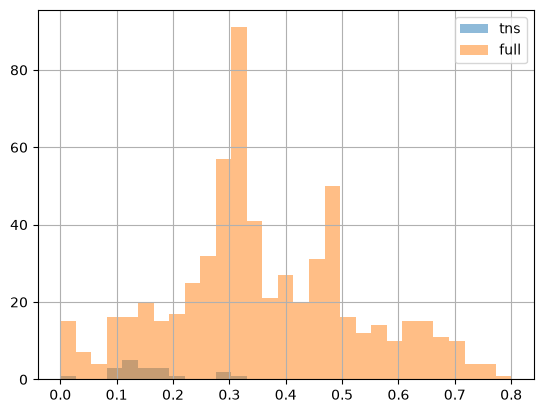

In [12]:
bins = np.linspace(0,0.8,30)
tns.Redshift.hist(bins=bins,alpha=0.5,label='tns')
full.z.hist(bins=bins,alpha=0.5,label='full')
plt.legend()

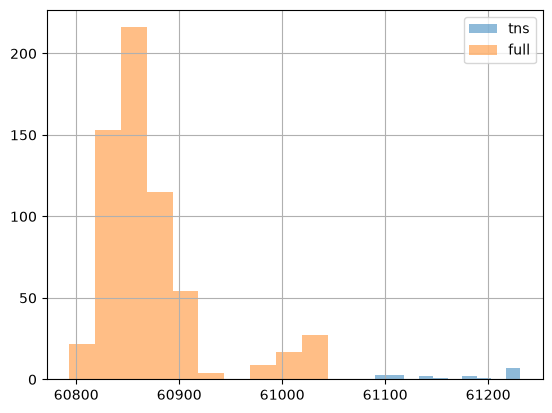

In [13]:
from astropy.time import Time

date_strs = [str(x) for x in tns["Discovery Date (UT)"]]
tns["mjd"] = Time(date_strs, format="iso").mjd
tns.mjd.hist(alpha=0.5,label="tns")
full.t0.hist(alpha=0.5,label="full")
plt.legend()

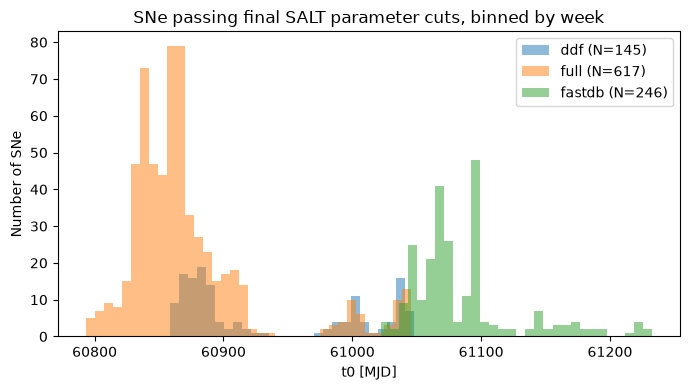

In [14]:
# Number of SNe binned by t0 (final SALT parameter cuts), weekly bins
fig = plt.figure(figsize=(7,4))

for label,df in zip(["ddf","full","fastdb"],[ddf, full, fastdb]):

    t0_final = df["t0"].to_numpy()
    
    week_bins = np.arange(t0_final.min(), t0_final.max() + 7, 7)
    
    ax = plt.subplot()
    ax.hist(t0_final, bins=week_bins, alpha=0.5, label=f"{label} (N={len(t0_final)})")
    ax.set(xlabel="t0 [MJD]", ylabel="Number of SNe",
           title=f"SNe passing final SALT parameter cuts, binned by week")
    # plt.yscale("log")
    plt.tight_layout()
plt.legend()
plt.show()

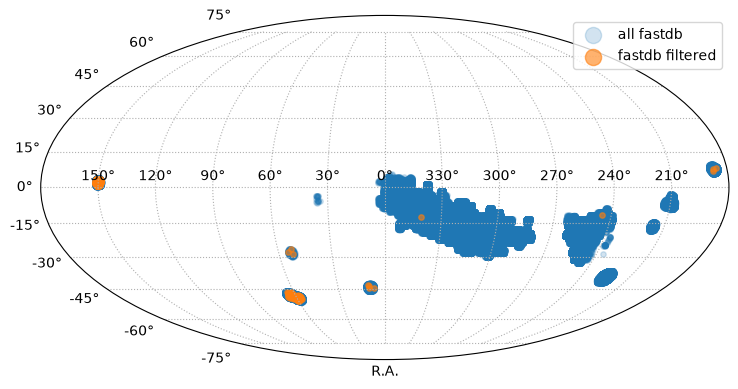

246


In [15]:
all_fastdb = read_parquet("../../rubin_alerts/data/all_objects_071726.parquet")

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111, projection='mollweide')

plot_radec(all_fastdb["ra"].to_numpy(dtype=float), all_fastdb["dec"].to_numpy(dtype=float),
           s=15, alpha=0.2, label="all fastdb")
plot_radec(fastdb["ra"].to_numpy(dtype=float), fastdb["dec"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="fastdb filtered")

tick_vals = np.array([-150,-120,-90,-60,-30,0,30,60,90,120,150])
tick_labels = [f"{int(np.remainder(CENTER - t, 360))}°" for t in tick_vals]
ax.set_xticks(np.radians(tick_vals))
ax.set_xticklabels(tick_labels)

ax.grid(True, linestyle=':')
ax.legend(markerscale=3, loc='upper right')
ax.set_xlabel("R.A.")
plt.tight_layout()
plt.show()
print(len(fastdb))

In [ ]:
all_fastdb = read_parquet("../../rubin_alerts/data/all_objects_071726.parquet")
nightly_sim_ddf = pd.read_csv("data/rubin_nightsum_snia_lcfit_results_ddf.csv")
# Number of SNe binned by t0 (final SALT parameter cuts), weekly bins
fig = plt.figure(figsize=(7,4))

def get_t0(flux,isdet,mjd):
    maxidx = np.argmax(flux[isdet])
    return np.float64(mjd[isdet][maxidx])
    
all_fastdb = all_fastdb.map_rows(get_t0, columns=["lightcurve.flux","lightcurve.isdet","lightcurve.mjd"],
                                row_container="args", output_names=["t0"], 
                                append_columns=True)

for label,df in zip(["nightly sim ddf","fastdb","all_fastdb"],[nightly_sim_ddf, fastdb, all_fastdb]):

    t0_final = df["t0"].to_numpy()
    
    week_bins = np.arange(t0_final.min(), t0_final.max() + 7, 7)
    
    ax = plt.subplot()
    ax.hist(t0_final, bins=week_bins, alpha=0.5, label=f"{label} (N={len(t0_final)})")
    ax.set(xlabel="t0 [MJD]", ylabel="Number of SNe",
           title=f"SNe passing final SALT parameter cuts, binned by week")
    # plt.yscale("log")
plt.tight_layout()
plt.yscale('log')
plt.legend()
plt.show()